In [22]:
from pathlib import Path
from IPython.display import HTML

import numpy as np
import pandas as pd

zs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999, 1.0], dtype=float)
one_link_latency_sec = 0.015107

common_thresholds = {
    "oneq_threshold": 0.999,
    "twoq_threshold": 0.9991,
    "meas_threshold": 0.996,
    "init_threshold": 0.99,
    "bell_threshold": 0.965,
    "t2_threshold_sec": 2.0,
}

thresholds = pd.DataFrame(
    [
        {"topology": "line_2", **common_thresholds},
        {"topology": "line_3", **common_thresholds},
        {"topology": "line_6", **common_thresholds},
    ]
)

rows = []
for _, threshold_row in thresholds.iterrows():
    for z in zs:
        idle_pz_threshold = (1.0 - np.exp(-one_link_latency_sec / threshold_row["t2_threshold_sec"])) / 2.0
        idle_pz = idle_pz_threshold * (1.0 - z)
        rows.append(
            {
                "topology": threshold_row["topology"],
                "z": z,
                "oneq": threshold_row["oneq_threshold"] + (1 - threshold_row["oneq_threshold"]) * z,
                "twoq": threshold_row["twoq_threshold"] + (1 - threshold_row["twoq_threshold"]) * z,
                "measurement": threshold_row["meas_threshold"] + (1 - threshold_row["meas_threshold"]) * z,
                "initialization": threshold_row["init_threshold"] + (1 - threshold_row["init_threshold"]) * z,
                "physical_bell_pair": threshold_row["bell_threshold"] + (1 - threshold_row["bell_threshold"]) * z,
                "idle_t2_sec": min(
                    -one_link_latency_sec / np.log(1.0 - 2.0 * idle_pz) if idle_pz > 0.0 else 199.99,
                    199.99,
                ),
            }
        )

z_table = pd.DataFrame(rows)
z_table = z_table.round(6)

runner_config_table = z_table.rename(
    columns={
        "oneq": "gate_fidelity",
        "twoq": "two_qubit_gate_fidelity",
        "measurement": "measurement_fidelity",
        "initialization": "initialization_fidelity",
        "physical_bell_pair": "physical_bell_pair_fidelity",
    }
)

config_output_path = Path("./config/generated_configs/z_plot_param_grid.json")
config_output_path.parent.mkdir(parents=True, exist_ok=True)
runner_config_table.to_json(config_output_path, orient="records", indent=2)

html_table = z_table.to_html(index=False, classes="raw-table")

display(
    HTML(
        f"""
        <style>
            .scroll-table {{
                max-height: 500px;
                overflow-y: auto;
                overflow-x: auto;
                border: 1px solid #ccc;
            }}
            .raw-table {{
                border-collapse: collapse;
                width: 100%;
            }}
            .raw-table th,
            .raw-table td {{
                padding: 6px 10px;
                border: 1px solid #ddd;
                text-align: left;
                white-space: nowrap;
            }}
            .raw-table th {{
                position: sticky;
                top: 0;
                background: white;
                z-index: 1;
            }}
        </style>
        <div class="scroll-table">
            {html_table}
        </div>
        """
    )
)


topology,z,oneq,twoq,measurement,initialization,physical_bell_pair,idle_t2_sec
line_2,0.000,0.999000,0.999100,0.996000,0.99000,0.965000,2.000000
line_2,0.200,0.999200,0.999280,0.996800,0.99200,0.972000,2.501893
line_2,0.400,0.999400,0.999460,0.997600,0.99400,0.979000,3.338379
line_2,0.600,0.999600,0.999640,0.998400,0.99600,0.986000,5.011350
line_2,0.800,0.999800,0.999820,0.999200,0.99800,0.993000,10.030260
line_2,0.900,0.999900,0.999910,0.999600,0.99900,0.996500,20.068076
line_2,0.910,0.999910,0.999919,0.999640,0.99910,0.996850,22.298701
line_2,0.920,0.999920,0.999928,0.999680,0.99920,0.997200,25.086983
line_2,0.930,0.999930,0.999937,0.999720,0.99930,0.997550,28.671917
line_2,0.940,0.999940,0.999946,0.999760,0.99940,0.997900,33.451829


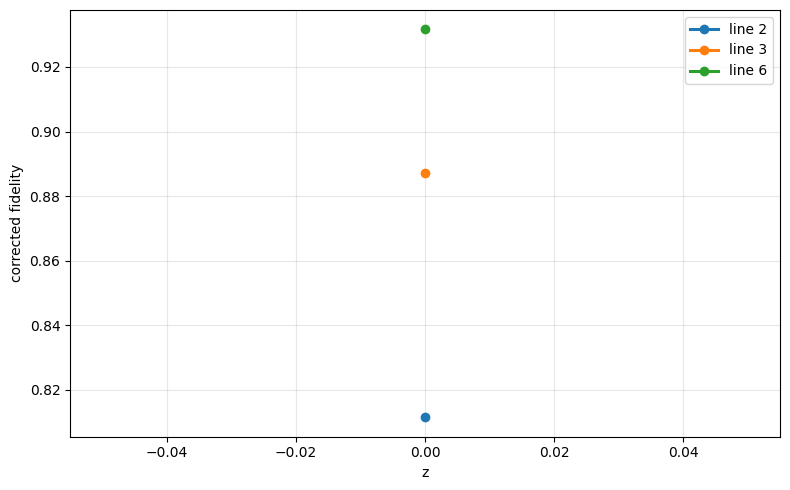

,topology,z,fidelity_mean,total_rows,run_count
0,line_2,0.0,0.811520,100000,4
1,line_3,0.0,0.887160,100000,4
2,line_6,0.0,0.931609,70346,4


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt

processed_dir = Path("./log/runner_May3rd_processed/z_param_grid")
key_columns = [
    "topology",
    "gate_fidelity",
    "two_qubit_gate_fidelity",
    "measurement_fidelity",
    "initialization_fidelity",
    "idle_t2_sec",
    "physical_bell_pair_fidelity",
]

grid_df = runner_config_table[key_columns].copy()
grid_df[key_columns[1:]] = grid_df[key_columns[1:]].round(6)

rows = []
for path in sorted(processed_dir.iterdir()):
    if not path.is_file():
        continue

    latency_ps, fidelity_corrected, rows_processed = [
        part.strip() for part in path.read_text().strip().split(",")
    ]
    metadata = {}
    for chunk in path.name.split(","):
        if "=" not in chunk:
            continue
        key, value = chunk.split("=", 1)
        metadata[key] = value

    rows.append(
        {
            "topology": path.name.split("_2G,", 1)[0],
            "gate_fidelity": round(float(metadata["gate"]), 6),
            "two_qubit_gate_fidelity": round(float(metadata["twoq"]), 6),
            "measurement_fidelity": round(float(metadata["meas"]), 6),
            "initialization_fidelity": round(float(metadata["prep"]), 6),
            "idle_t2_sec": round(float(metadata["T2"]), 6),
            "physical_bell_pair_fidelity": round(float(metadata["physbell"]), 6),
            "fidelity_corrected": float(fidelity_corrected),
            "rows_processed": int(rows_processed),
        }
    )

processed_df = pd.DataFrame(rows)
plot_df = processed_df.merge(grid_df, on=key_columns, how="left")
plot_df = plot_df.merge(
    z_table[["topology", "z", "idle_t2_sec"]],
    on=["topology", "idle_t2_sec"],
    how="left",
)

summary_df = (
    plot_df.assign(
        weighted_fidelity=plot_df["fidelity_corrected"] * plot_df["rows_processed"]
    )
    .groupby(["topology", "z"], as_index=False)
    .agg(
        weighted_fidelity=("weighted_fidelity", "sum"),
        total_rows=("rows_processed", "sum"),
        run_count=("fidelity_corrected", "count"),
    )
    .sort_values(["topology", "z"])
)

summary_df["fidelity_mean"] = (
    summary_df["weighted_fidelity"] / summary_df["total_rows"]
)

topology_colors = {
    "line_2": "tab:blue",
    "line_3": "tab:orange",
    "line_6": "tab:green",
}

fig, ax = plt.subplots(figsize=(8, 5))

for topology in ["line_2", "line_3", "line_6"]:
    topology_df = summary_df[summary_df["topology"] == topology].sort_values("z")

    ax.plot(
        topology_df["z"],
        topology_df["fidelity_mean"],
        marker="o",
        linewidth=2.2,
        markersize=6,
        color=topology_colors[topology],
        label=topology.replace("_", " "),
    )

ax.set_xlabel("z")
ax.set_ylabel("corrected fidelity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(
    summary_df[["topology", "z", "fidelity_mean", "total_rows", "run_count"]].round(
        {
            "z": 3,
            "fidelity_mean": 6,
        }
    )
)


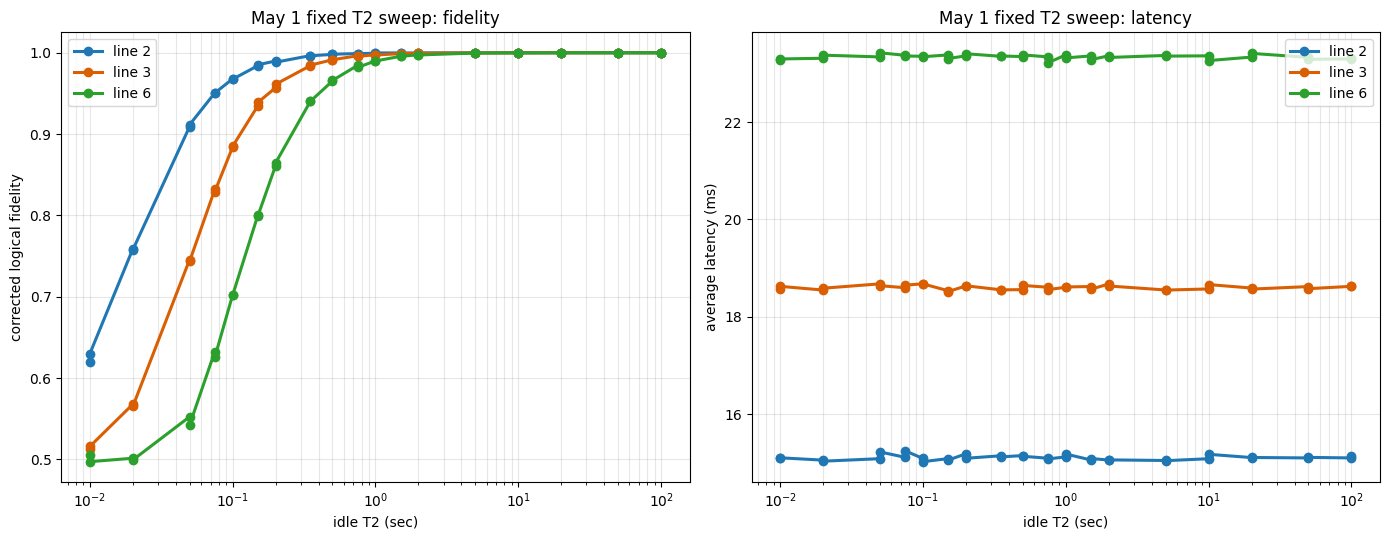

,topology,idle_t2_sec,fidelity_corrected,avg_latency_ps,run_count
0,line_2,0.01,0.619500,1.510899e+10,30000
1,line_2,0.01,0.629900,1.510604e+10,10000
2,line_2,0.02,0.758800,1.505788e+10,30000
3,line_2,0.02,0.757700,1.503666e+10,10000
4,line_2,0.05,0.909333,1.508822e+10,30000
...,...,...,...,...,...
103,line_6,20.00,1.000000,2.340926e+10,10000
104,line_6,50.00,1.000000,2.332758e+10,23857
105,line_6,50.00,1.000000,2.328708e+10,10000
106,line_6,100.00,1.000000,2.329770e+10,24057


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt

processed_dir = Path("./log/runner_May1st_processed/t2_sweep")

rows = []
for path in sorted(processed_dir.iterdir()):
    if not path.is_file():
        continue

    latency_ps, fidelity_corrected, rows_processed = [
        part.strip() for part in path.read_text().strip().split(",")
    ]

    metadata = {}
    for chunk in path.name.split(","):
        if "=" not in chunk:
            continue
        key, value = chunk.split("=", 1)
        metadata[key] = value

    rows.append(
        {
            "topology": path.name.split("_2G,", 1)[0],
            "idle_t2_sec": float(metadata["T2"]),
            "idle_t1_sec": float(metadata["T1"]),
            "fidelity_corrected": float(fidelity_corrected),
            "avg_latency_ps": float(latency_ps),
            "run_count": int(rows_processed),
        }
    )

t2_df = pd.DataFrame(rows).sort_values(["topology", "idle_t2_sec"]).reset_index(drop=True)

topologies = ["line_2", "line_3", "line_6"]
colors = {
    "line_2": "#1f77b4",
    "line_3": "#d95f02",
    "line_6": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax_fidelity, ax_latency = axes

for topology in topologies:
    topology_df = t2_df[t2_df["topology"] == topology].sort_values("idle_t2_sec")

    ax_fidelity.semilogx(
        topology_df["idle_t2_sec"],
        topology_df["fidelity_corrected"],
        marker="o",
        markersize=6,
        linewidth=2.2,
        color=colors[topology],
        label=topology.replace("_", " "),
    )

    ax_latency.semilogx(
        topology_df["idle_t2_sec"],
        topology_df["avg_latency_ps"] * 1e-9,
        marker="o",
        markersize=6,
        linewidth=2.2,
        color=colors[topology],
        label=topology.replace("_", " "),
    )

ax_fidelity.set_xlabel("idle T2 (sec)")
ax_fidelity.set_ylabel("corrected logical fidelity")
ax_fidelity.set_title("May 1 T2 sweep: fidelity")
ax_fidelity.grid(True, alpha=0.3, which="both")
ax_fidelity.legend()

ax_latency.set_xlabel("idle T2 (sec)")
ax_latency.set_ylabel("average latency (ms)")
ax_latency.set_title("May 1 T2 sweep: latency")
ax_latency.grid(True, alpha=0.3, which="both")
ax_latency.legend()

plt.tight_layout()
plt.show()

display(
    t2_df[["topology", "idle_t2_sec", "fidelity_corrected", "avg_latency_ps", "run_count"]].round(
        {
            "idle_t2_sec": 3,
            "fidelity_corrected": 6,
            "avg_latency_ps": 2,
        }
    )
)
